In [1]:
import logging
import os
import time
import unicodedata
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import pandas as pd
import requests
from bs4 import BeautifulSoup
from plotly.offline import plot

Для того, чтобы получить датасет, необходимо получить доступ к тексту юридических документов. Для этого необходимо создать парсер, который будет легально собирать информацию с бесплатных веб-порталов. Поскольку информация с форумов по юридическим консультациям не распространяется свободно, пока будет произведен парсинг только нормативно-правовых актов РФ (кодексов РФ и нескольких Федеральных законов).

In [2]:
class BasicWebParser:
    """
    Базовый парсер веб-страниц
    """

    def __init__(self, delay=1):
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
            'Accept-Language': 'ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7',
            'Accept-Encoding': 'gzip, deflate',
            'Connection': 'keep-alive',
        })
        self.delay = delay
        self.setup_logging()

    def setup_logging(self):
        logging.basicConfig(
            level=logging.INFO,
            format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
        )
        self.logger = logging.getLogger(__name__)

    def fetch_page(self, url, timeout=10):
        """
        Загрузка страницы с обработкой ошибок
        """
        try:
            time.sleep(self.delay) 
            response = self.session.get(url, timeout=timeout)
            response.raise_for_status()

            if response.encoding is None:
                response.encoding = 'utf-8'

            self.logger.info(f"Успешно загружено: {url} ({len(response.content)} байт)")
            return response

        except requests.exceptions.RequestException as e:
            self.logger.error(f"Ошибка загрузки {url}: {e}")
            return None

    def parse_html(self, html_content, parser='html.parser'):
        """
        Парсинг HTML контента
        """
        return BeautifulSoup(html_content, parser)

    def parse_site(self, url, parser='html.parser', timeout=10):
        response = self.fetch_page(url, timeout)
        if response:
            return self.parse_html(response.content, parser)
        return None

    def extract_links(self, soup, base_url):
        """
        Извлечение всех ссылок со страницы
        """
        links = []
        for link in soup.find_all('a', href=True):
            href = link['href']
            text = link.get_text(strip=True)

            full_url = urljoin(base_url, href)

            links.append({
                'url': full_url,
                'text': text,
                'title': link.get('title', '')
            })

        return links

    def extract_text(self, soup):
        """
        Извлечение текста из HTML
        """
        ocur = soup.find_all('section')[0]
        return unicodedata.normalize('NFKD', ocur.get_text(strip=False)).replace('\n', ' ').replace('\r', ' ').replace('\t', ' ').replace(r' +', ' ').strip()

    def save_to_csv(self, data, filename):
        """
        Сохранение данных в CSV
        """
        if data:
            df = pd.DataFrame(data)
            df.to_csv(filename, index=False, encoding='utf-8-sig')
            self.logger.info(f"Сохранено {len(data)} записей в {filename}")
            return True
        return False


In [ ]:
parser = BasicWebParser(delay=2)

urls = {
    'ГК РФ': 'https://base.garant.ru/10164072/',
    'ТК РФ': 'https://base.garant.ru/12125268/',
    'НК РФ': 'https://base.garant.ru/10900200/',
    'КоАП РФ': 'https://base.garant.ru/12125267/',
    'УК РФ': 'https://base.garant.ru/10108000/',
    'ГПК РФ': 'https://base.garant.ru/12128809/',
    'УПК РФ': 'https://base.garant.ru/12125178/',
    'ЗК РФ': 'https://base.garant.ru/12124624/',
    'ЖК РФ': 'https://base.garant.ru/12138291/',
    'АПК РФ': 'https://base.garant.ru/12127526/',
    'СК РФ': 'https://base.garant.ru/10105807/',
    'БК РФ': 'https://base.garant.ru/12112604/',
    'ЛК РФ': 'https://base.garant.ru/12150845/',
    'ГрК РФ': 'https://base.garant.ru/12138258/',
}

for name, url in urls.items():
    print(name)
    response = parser.fetch_page(url)

    possible_parts = ['часть', 'раздел', 'подраздел', 'глава', 'статья', '§']

    if response:
        soup = parser.parse_html(response.content)
        links = parser.extract_links(soup, url)

    metadata = {
        'Название нормативно-правового акта': name,
        'Часть': '',
        'Раздел': '',
        'Подраздел': '',
        'Глава': '',
        'Параграф': '',
        'Статья': '',
    }
    proper_links = []

    for link in links:
        if len(link['text']) != 0:
            prefix = link['text'].split()[0].lower()
            if prefix in possible_parts:
                if prefix == 'часть':
                    metadata['Часть'] = link['text']
                elif prefix == 'раздел':
                    metadata['Раздел'] = link['text']
                elif prefix == 'подраздел':
                    metadata['Подраздел'] = link['text']
                elif prefix == 'глава':
                    metadata['Глава'] = link['text']
                elif prefix == '§':
                    metadata['Параграф'] = link['text']
                elif prefix == 'статья':
                    metadata['Статья'] = link['text']
                    try:
                        response = parser.fetch_page(link['url'])
                    except Exception as e:
                        print(link['url'], e)
                        response = parser.fetch_page(link['url']).rstrip(':')
                    if response:
                        soup = parser.parse_html(response.content)
                        content = parser.extract_text(soup)
                        link['content'] = content
                    link['metadata'] = metadata.copy()
                    proper_links.append(link)

    parser.save_to_csv(proper_links, os.path.join('csvs', f'{name}.csv'))


In [28]:
import glob

path = 'csvs' # use your path
all_files = glob.glob(os.path.join(path , "*.csv"))

print(all_files)

li = []

for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    li.append(df.drop(columns=['title', 'url', 'text']))

frame = pd.concat(li, axis=0, ignore_index=True)

['csvs\\АПК РФ.csv', 'csvs\\БК РФ.csv', 'csvs\\ГК РФ.csv', 'csvs\\ГПК РФ.csv', 'csvs\\ГрК РФ.csv', 'csvs\\ЖК РФ.csv', 'csvs\\ЗК РФ.csv', 'csvs\\КоАП РФ.csv', 'csvs\\ЛК РФ.csv', 'csvs\\НК РФ.csv', 'csvs\\СК РФ.csv', 'csvs\\ТК РФ.csv', 'csvs\\УК РФ.csv', 'csvs\\УПК РФ.csv']


In [29]:
for col in ['Название нормативно-правового акта', 'Раздел', 'Подраздел', 'Глава', 'Параграф', 'Статья']:
    frame[col] = frame['metadata'].apply(lambda x: eval(x)[col])

In [30]:
frame

,content,metadata,Название нормативно-правового акта,Раздел,Подраздел,Глава,Параграф,Статья
0,Статья 1. Осуществление правосудия арбитражным...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ,Раздел I. Общие положения (ст. 1 - 124),,Глава 1. Основные положения (ст. 1 - 16),,Статья 1. Осуществление правосудия арбитражным...
1,Статья 2. Задачи судопроизводства в арбитражны...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ,Раздел I. Общие положения (ст. 1 - 124),,Глава 1. Основные положения (ст. 1 - 16),,Статья 2. Задачи судопроизводства в арбитражны...
2,Статья 3. Законодательство о судопроизводстве ...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ,Раздел I. Общие положения (ст. 1 - 124),,Глава 1. Основные положения (ст. 1 - 16),,Статья 3. Законодательство о судопроизводстве ...
3,Статья 4. Право на обращение в арбитражный су...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ,Раздел I. Общие положения (ст. 1 - 124),,Глава 1. Основные положения (ст. 1 - 16),,Статья 4. Право на обращение в арбитражный суд
4,Статья 5. Независимость судей арбитражных суд...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ,Раздел I. Общие положения (ст. 1 - 124),,Глава 1. Основные положения (ст. 1 - 16),,Статья 5. Независимость судей арбитражных судов
...,...,...,...,...,...,...,...,...
7375,Статья 473.7. Выдача исполнительного листа и н...,{'Название нормативно-правового акта': 'УПК РФ...,УПК РФ,"Раздел XVIII. Порядок взаимодействия судов, пр...",,Глава 55.1. Производство по рассмотрению и раз...,,Статья 473.7. Выдача исполнительного листа и н...
7376,Статья 474. Оформление процессуальных действи...,{'Название нормативно-правового акта': 'УПК РФ...,УПК РФ,Раздел XIX. Использование в уголовном судопрои...,,Глава 56. Порядок использования электронных до...,,Статья 474. Оформление процессуальных действий...
7377,Статья 474.1. Порядок использования электронны...,{'Название нормативно-правового акта': 'УПК РФ...,УПК РФ,Раздел XIX. Использование в уголовном судопрои...,,Глава 56. Порядок использования электронных до...,,Статья 474.1. Порядок использования электронны...
7378,Статья 474.2. Порядок использования электронны...,{'Название нормативно-правового акта': 'УПК РФ...,УПК РФ,Раздел XIX. Использование в уголовном судопрои...,,Глава 56. Порядок использования электронных до...,,Статья 474.2. Порядок использования электронны...


Проверка пропусков данных 

In [47]:
duplicates = frame.duplicated(subset=['content', 'Название нормативно-правового акта'])
print(duplicates.value_counts())

False    7379
True        1
Name: count, dtype: int64


In [48]:
frame[frame[['content', 'Название нормативно-правового акта']].duplicated()]

,content,metadata,Название нормативно-правового акта,Раздел,Подраздел,Глава,Параграф,Статья
6285,Статья 279. Гарантии руководителю организации ...,{'Название нормативно-правового акта': 'ТК РФ'...,ТК РФ,Раздел XIV. Заключительные положения (ст. 420 ...,,Глава 62. Ответственность за нарушение трудово...,,статья 279


In [49]:
frame[frame['content'].apply(lambda x: 'Статья 279. Гарантии руководителю' in x)]

,content,metadata,Название нормативно-правового акта,Раздел,Подраздел,Глава,Параграф,Статья
6069,Статья 279. Гарантии руководителю организации ...,{'Название нормативно-правового акта': 'ТК РФ'...,ТК РФ,Раздел XII. Особенности регулирования труда от...,,Глава 43. Особенности регулирования труда руко...,,Статья 279. Гарантии руководителю организации ...
6285,Статья 279. Гарантии руководителю организации ...,{'Название нормативно-правового акта': 'ТК РФ'...,ТК РФ,Раздел XIV. Заключительные положения (ст. 420 ...,,Глава 62. Ответственность за нарушение трудово...,,статья 279


Как видно, при парсинге произошла небольшая ошибка. Необходимо удалить запись №6285, чтобы избежать дупликатов в базе знаний. 

In [50]:
frame = frame[~frame.duplicated(subset=['content', 'Название нормативно-правового акта'])]
frame

,content,metadata,Название нормативно-правового акта,Раздел,Подраздел,Глава,Параграф,Статья
0,Статья 1. Осуществление правосудия арбитражным...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ,Раздел I. Общие положения (ст. 1 - 124),,Глава 1. Основные положения (ст. 1 - 16),,Статья 1. Осуществление правосудия арбитражным...
1,Статья 2. Задачи судопроизводства в арбитражны...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ,Раздел I. Общие положения (ст. 1 - 124),,Глава 1. Основные положения (ст. 1 - 16),,Статья 2. Задачи судопроизводства в арбитражны...
2,Статья 3. Законодательство о судопроизводстве ...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ,Раздел I. Общие положения (ст. 1 - 124),,Глава 1. Основные положения (ст. 1 - 16),,Статья 3. Законодательство о судопроизводстве ...
3,Статья 4. Право на обращение в арбитражный су...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ,Раздел I. Общие положения (ст. 1 - 124),,Глава 1. Основные положения (ст. 1 - 16),,Статья 4. Право на обращение в арбитражный суд
4,Статья 5. Независимость судей арбитражных суд...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ,Раздел I. Общие положения (ст. 1 - 124),,Глава 1. Основные положения (ст. 1 - 16),,Статья 5. Независимость судей арбитражных судов
...,...,...,...,...,...,...,...,...
7375,Статья 473.7. Выдача исполнительного листа и н...,{'Название нормативно-правового акта': 'УПК РФ...,УПК РФ,"Раздел XVIII. Порядок взаимодействия судов, пр...",,Глава 55.1. Производство по рассмотрению и раз...,,Статья 473.7. Выдача исполнительного листа и н...
7376,Статья 474. Оформление процессуальных действи...,{'Название нормативно-правового акта': 'УПК РФ...,УПК РФ,Раздел XIX. Использование в уголовном судопрои...,,Глава 56. Порядок использования электронных до...,,Статья 474. Оформление процессуальных действий...
7377,Статья 474.1. Порядок использования электронны...,{'Название нормативно-правового акта': 'УПК РФ...,УПК РФ,Раздел XIX. Использование в уголовном судопрои...,,Глава 56. Порядок использования электронных до...,,Статья 474.1. Порядок использования электронны...
7378,Статья 474.2. Порядок использования электронны...,{'Название нормативно-правового акта': 'УПК РФ...,УПК РФ,Раздел XIX. Использование в уголовном судопрои...,,Глава 56. Порядок использования электронных до...,,Статья 474.2. Порядок использования электронны...


### Анализ иерархии и полноты данных

Проверим долю статей, относительно которых определен раздел, подраздел, параграф, статья.  

In [7]:
hierarchy_levels = ['Название нормативно-правового акта', 'Раздел', 'Подраздел', 'Глава', 'Параграф', 'Статья']
for level in hierarchy_levels:
    coverage = frame[level].apply(lambda x: len(x) != 0).mean() * 100
    print(f"{level}: заполнено {coverage:.1f}%")

Название нормативно-правового акта: заполнено 100.0%
Раздел: заполнено 92.4%
Подраздел: заполнено 25.1%
Глава: заполнено 100.0%
Параграф: заполнено 23.9%
Статья: заполнено 100.0%


Итог: в каждом нормативно-правовом акте есть главы, почти в каждом есть разделы, лишь в небольшом количестве актов содержатся подразделы и параграфы.

### Частотный анализ по уровням

In [27]:
documents = frame['Название нормативно-правового акта'].value_counts()

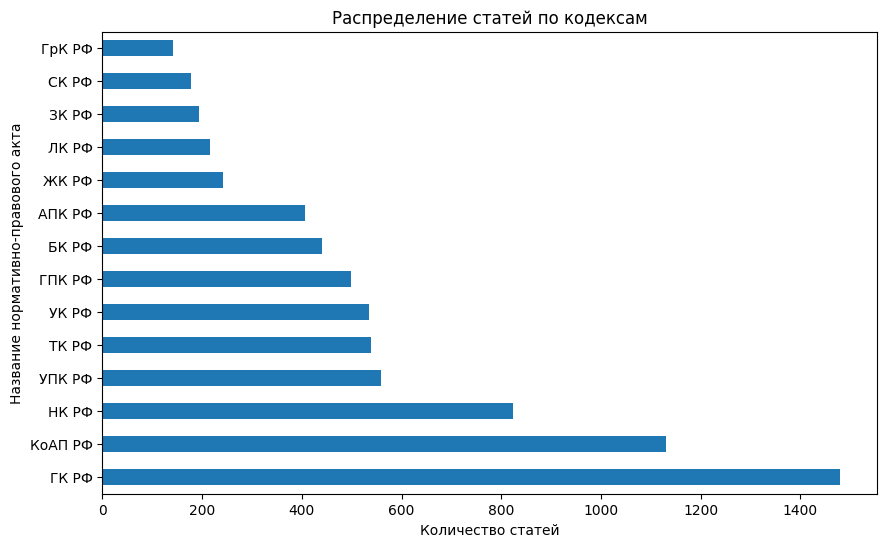

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Распределение статей по кодексам")
documents.plot(kind='barh')
plt.xlabel('Количество статей')
plt.show()

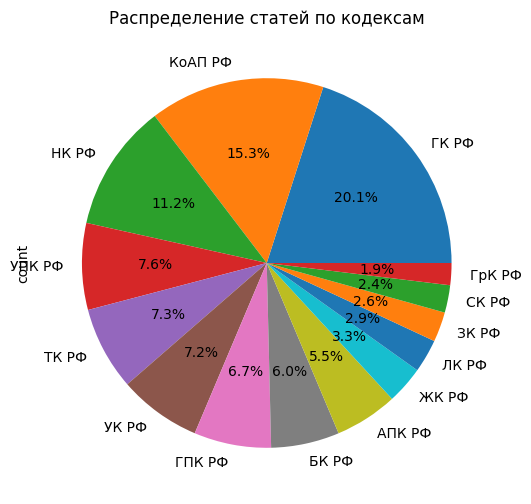

In [31]:
plt.figure(figsize=(10, 6))
plt.title("Распределение статей по кодексам")
documents.plot(kind='pie', autopct='%1.1f%%')
plt.show()

Итог: больше всего статей в ГК РФ.